# ML-QEM: LiH (6-Qubit) Training & Comparison

Trains RF and MLP error mitigation models on 6-qubit LiH data,
then compares with the 2-qubit H₂ results to demonstrate scalability.

**Feature vector (33 features):**

| # | Feature | Description |
|---|---------|-------------|
| 1 | `noisy_exp_val` | Noisy ⟨O⟩ — implicitly encodes θ |
| 2–13 | `x_q0..x_q5, z_q0..z_q5` | Symplectic Pauli encoding (6 qubits) |
| 14–15 | `n_2q, n_sx` | Gate counts |
| 16–33 | `T1, T2, ro` × 6 qubits | Per-qubit noise params, masked |

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import joblib
import itertools
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}, device: {DEVICE}')
print('All imports OK')

PyTorch 2.11.0+cpu, device: cpu
All imports OK


## 1. Load LiH Dataset

In [3]:
ideal_data    = np.load('lih_ideal_data.npy')
noisy_data    = np.load('lih_noisy_data.npy')
theta_samples = np.load('lih_theta_samples.npy')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS     = meta['n_qubits']
N_2Q         = meta['n_2q_gates']
N_SX         = meta['n_sx_gates']

N_TRAIN = 1800
N_TEST  = 200

ideal_train = ideal_data[:N_TRAIN]
noisy_train = noisy_data[:N_TRAIN]
ideal_test  = ideal_data[N_TRAIN:]
noisy_test  = noisy_data[N_TRAIN:]

print(f'LiH dataset: {ideal_data.shape[0]} samples, {ideal_data.shape[1]} Pauli terms, {N_QUBITS} qubits')
print(f'Train: {N_TRAIN} θ values | Test: {N_TEST} θ values')
print(f'Gate counts: N_2Q={N_2Q}, N_SX={N_SX}')

LiH dataset: 2000 samples, 62 Pauli terms, 6 qubits
Train: 1800 θ values | Test: 200 θ values
Gate counts: N_2Q=15, N_SX=48


## 2. Per-Qubit Noise Parameters

In [4]:
backend = FakeJakartaV2()
props   = backend.properties()

qubit_props = {}
for q in range(N_QUBITS):
    t1  = props.qubit_property(q, 'T1')[0] * 1e6
    t2  = props.qubit_property(q, 'T2')[0] * 1e6
    err = props.qubit_property(q, 'readout_error')[0]
    qubit_props[q] = {'T1': t1, 'T2': t2, 'readout_error': err}
    print(f'  Qubit {q}: T1={t1:.1f}µs  T2={t2:.1f}µs  ro={err:.4f}')

  Qubit 0: T1=81.8µs  T2=41.5µs  ro=0.0210
  Qubit 1: T1=134.6µs  T2=27.5µs  ro=0.0205
  Qubit 2: T1=137.8µs  T2=20.3µs  ro=0.0160
  Qubit 3: T1=112.7µs  T2=34.2µs  ro=0.0253
  Qubit 4: T1=117.5µs  T2=74.6µs  ro=0.0490
  Qubit 5: T1=146.2µs  T2=56.9µs  ro=0.0555


## 3. Build 33-Feature Vectors

In [5]:
def pauli_to_symplectic(pauli_str):
    p = Pauli(pauli_str)
    return np.concatenate([p.x.astype(int), p.z.astype(int)])

SYMPLECTIC = {label: pauli_to_symplectic(label) for label in PAULI_LABELS}

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([
            qubit_props[q]['T1']            * active,
            qubit_props[q]['T2']            * active,
            qubit_props[q]['readout_error'] * active,
        ])
    return feats

def build_features(noisy_subset, ideal_subset, observable_indices):
    N = len(noisy_subset)
    rows_X, rows_y = [], []
    for obs_idx in observable_indices:
        label       = PAULI_LABELS[obs_idx]
        symp        = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(N):
            rows_X.append([
                noisy_subset[i, obs_idx],
                *symp,
                N_2Q, N_SX,
                *noise_feats,
            ])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

# All non-trivial observables (skip IIIIII at index 0)
ALL_OBS = list(range(1, len(PAULI_LABELS)))  # 61 observables

X_train_raw, y_train = build_features(noisy_train, ideal_train, ALL_OBS)
X_test_raw,  y_test  = build_features(noisy_test,  ideal_test,  ALL_OBS)

print(f'Training set: {X_train_raw.shape}  = {N_TRAIN} θ × {len(ALL_OBS)} obs')
print(f'Test set:     {X_test_raw.shape}  = {N_TEST} θ × {len(ALL_OBS)} obs')
print(f'Features per sample: {X_train_raw.shape[1]}')

Training set: (109800, 33)  = 1800 θ × 61 obs
Test set:     (12200, 33)  = 200 θ × 61 obs
Features per sample: 33


## 4. Train Random Forest

In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_raw, y_train)

rf_train_pred = rf.predict(X_train_raw)
rf_test_pred  = rf.predict(X_test_raw)
baseline      = X_test_raw[:, 0]  # unmitigated = noisy value

rf_train_mae    = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae     = mean_absolute_error(y_test, rf_test_pred)
baseline_mae    = mean_absolute_error(y_test, baseline)

print(f'RF Training MAE  (seen θ):     {rf_train_mae:.4f}')
print(f'RF Test MAE      (unseen θ):   {rf_test_mae:.4f}')
print(f'Baseline MAE     (unmitigated):{baseline_mae:.4f}')
print(f'\nRF improvement: {baseline_mae / rf_test_mae:.1f}x')

# Save
joblib.dump(rf, 'lih_rf_mlqem.joblib')
print('Saved: lih_rf_mlqem.joblib')

RF Training MAE  (seen θ):     0.0067
RF Test MAE      (unseen θ):   0.0135
Baseline MAE     (unmitigated):0.0406

RF improvement: 3.0x
Saved: lih_rf_mlqem.joblib


## 5. Train MLP

In [7]:
# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32).to(DEVICE),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(DEVICE))

Xt_train, yt_train = to_tensors(X_train, y_train)
Xt_test,  yt_test  = to_tensors(X_test,  y_test)
train_loader = DataLoader(TensorDataset(Xt_train, yt_train),
                          batch_size=256, shuffle=True)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

def train_mlp(hidden_sizes, n_epochs=300, lr=1e-3, patience=25):
    n_feat = X_train.shape[1]
    model  = MLP(n_feat, hidden_sizes).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit   = nn.HuberLoss(delta=1.0)

    best_mae, best_state, no_improve = float('inf'), None, 0
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            te_mae = mean_absolute_error(y_test,
                model(Xt_test).cpu().numpy().ravel())
        if te_mae < best_mae - 1e-6:
            best_mae, best_state, no_improve = te_mae, \
                {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
        if no_improve >= patience: break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        tr = mean_absolute_error(y_train, model(Xt_train).cpu().numpy().ravel())
        te = mean_absolute_error(y_test,  model(Xt_test).cpu().numpy().ravel())
    return model, tr, te

# Ablation: 4 configs
configs = [(1, 64), (2, 64), (1, 128), (2, 128)]
print(f'{"Config":<12} {"Params":>8} {"Train MAE":>12} {"Test MAE":>12}')
print('-' * 48)

mlp_results = []
for depth, width in configs:
    hidden = [width] * depth
    model, tr_mae, te_mae = train_mlp(hidden)
    n_params = model.count_params()
    mlp_results.append({'depth': depth, 'width': width,
                        'n_params': n_params, 'train_mae': tr_mae,
                        'test_mae': te_mae, 'model': model})
    print(f'd{depth}_w{width:<6} {n_params:>8,} {tr_mae:>12.4f} {te_mae:>12.4f}')

best_mlp = min(mlp_results, key=lambda r: r['test_mae'])
print(f'\nBest MLP: d{best_mlp["depth"]}_w{best_mlp["width"]}, '
      f'test MAE = {best_mlp["test_mae"]:.4f}')

Config         Params    Train MAE     Test MAE
------------------------------------------------
d1_w64        2,369       0.0130       0.0131
d2_w64        6,657       0.0138       0.0139
d1_w128       4,737       0.0134       0.0135
d2_w128      21,505       0.0137       0.0138

Best MLP: d1_w64, test MAE = 0.0131


## 6. Results: RF vs MLP vs Unmitigated

In [8]:
print('=' * 56)
print(f'  LiH (6 qubits, 61 non-trivial observables)')
print(f'  Unmitigated MAE : {baseline_mae:.4f}')
print(f'  RF MAE          : {rf_test_mae:.4f}  ({baseline_mae/rf_test_mae:.1f}x improvement)')
print(f'  Best MLP MAE    : {best_mlp["test_mae"]:.4f}  ({baseline_mae/best_mlp["test_mae"]:.1f}x improvement)')
print('=' * 56)

  LiH (6 qubits, 61 non-trivial observables)
  Unmitigated MAE : 0.0406
  RF MAE          : 0.0135  (3.0x improvement)
  Best MLP MAE    : 0.0131  (3.1x improvement)


## 7. Energy Error on Test Set

Reconstruct the total energy $E(\theta) = \sum_k c_k \langle P_k \rangle$ and compare.

In [9]:
def reconstruct_energy(exp_vals_matrix, coeffs):
    return exp_vals_matrix @ np.array(coeffs)

E_ideal = reconstruct_energy(ideal_test, PAULI_COEFFS)
E_unm   = reconstruct_energy(noisy_test, PAULI_COEFFS)

# RF corrected
rf_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp  = SYMPLECTIC[label]
    nf    = qubit_noise_features(symp)
    N     = len(noisy_test)
    feats = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX),
        np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    rf_corrected[:, obs_idx] = rf.predict(feats)
E_rf = reconstruct_energy(rf_corrected, PAULI_COEFFS)

# MLP corrected
best_model = best_mlp['model']
best_model.eval()
mlp_corrected = noisy_test.copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp  = SYMPLECTIC[label]
    nf    = qubit_noise_features(symp)
    N     = len(noisy_test)
    feats_raw = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX),
        np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    feats_sc = scaler.transform(feats_raw)
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = best_model(
            torch.tensor(feats_sc, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy().ravel()
E_mlp = reconstruct_energy(mlp_corrected, PAULI_COEFFS)

E_EXACT = meta['exact_gs_energy']

print(f'Energy MAE on {N_TEST} test θ values:')
print(f'  Unmitigated : {mean_absolute_error(E_ideal, E_unm):.5f} Ha')
print(f'  RF          : {mean_absolute_error(E_ideal, E_rf):.5f} Ha')
print(f'  Best MLP    : {mean_absolute_error(E_ideal, E_mlp):.5f} Ha')
print(f'\n  Chemical accuracy: 0.00160 Ha (1 kcal/mol)')

Energy MAE on 200 test θ values:
  Unmitigated : 0.01202 Ha
  RF          : 0.00477 Ha
  Best MLP    : 0.00468 Ha

  Chemical accuracy: 0.00160 Ha (1 kcal/mol)


## 8. Comparison Plot: H₂ vs LiH Scalability

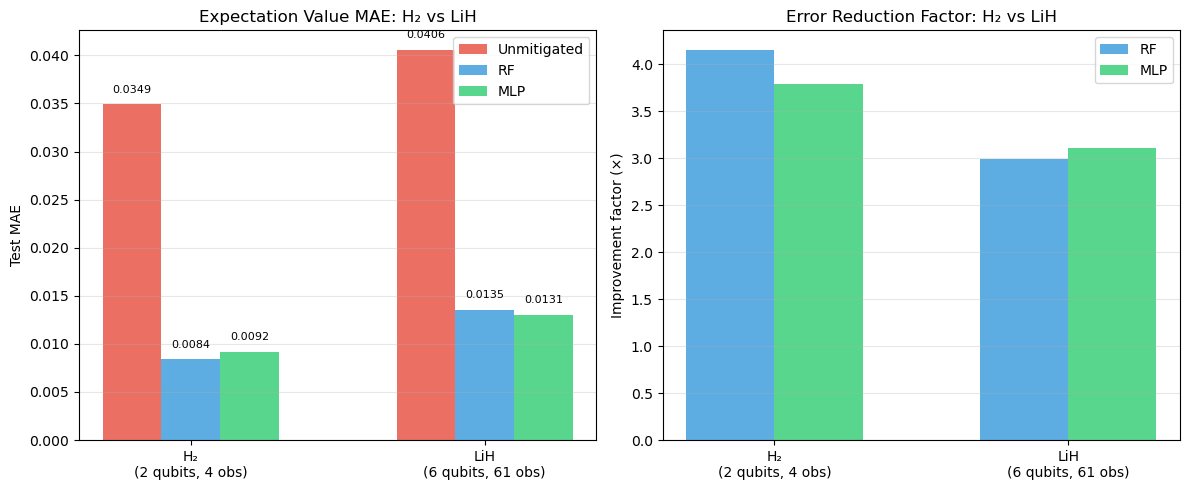

Saved: h2_vs_lih_scalability.png


In [12]:
# ── Enter H2 results from your earlier notebooks here ─────────────────────
# Update these numbers with your actual H2 results:
H2_RESULTS = {
    'unmitigated_mae': 0.0349,  # from training_RF.ipynb
    'rf_mae':          0.0084,  # from training_RF.ipynb
    'mlp_mae':         0.0092,  # from training_MLP.ipynb
    'n_qubits':        2,
    'n_paulis':        4,       # non-trivial terms
    'n_features':      13,
}

LIH_RESULTS = {
    'unmitigated_mae': baseline_mae,
    'rf_mae':          rf_test_mae,
    'mlp_mae':         best_mlp['test_mae'],
    'n_qubits':        N_QUBITS,
    'n_paulis':        len(ALL_OBS),
    'n_features':      X_train_raw.shape[1],
}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: MAE comparison
ax = axes[0]
x = [0, 1]
labels_x = ['H₂\n(2 qubits, 4 obs)', 'LiH\n(6 qubits, 61 obs)']
w = 0.2

for i, (name, color, key) in enumerate([
    ('Unmitigated', '#e74c3c', 'unmitigated_mae'),
    ('RF', '#3498db', 'rf_mae'),
    ('MLP', '#2ecc71', 'mlp_mae'),
]):
    vals = [H2_RESULTS[key], LIH_RESULTS[key]]
    bars = ax.bar([xi + (i-1)*w for xi in x], vals, w, label=name, color=color, alpha=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels_x)
ax.set_ylabel('Test MAE')
ax.set_title('Expectation Value MAE: H₂ vs LiH')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Right: Improvement factor
ax = axes[1]
rf_imp = [H2_RESULTS['unmitigated_mae'] / H2_RESULTS['rf_mae'],
          LIH_RESULTS['unmitigated_mae'] / LIH_RESULTS['rf_mae']]
mlp_imp = [H2_RESULTS['unmitigated_mae'] / H2_RESULTS['mlp_mae'],
           LIH_RESULTS['unmitigated_mae'] / LIH_RESULTS['mlp_mae']]

ax.bar([xi - 0.15 for xi in x], rf_imp, 0.3, label='RF', color='#3498db', alpha=0.8)
ax.bar([xi + 0.15 for xi in x], mlp_imp, 0.3, label='MLP', color='#2ecc71', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels_x)
ax.set_ylabel('Improvement factor (×)')
ax.set_title('Error Reduction Factor: H₂ vs LiH')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('h2_vs_lih_scalability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: h2_vs_lih_scalability.png')

## 8. Summary Table

In [13]:
print(f'{"":<20} {"H₂ (2q)":>12} {"LiH (6q)":>12}')
print('=' * 46)
print(f'{"Qubits":<20} {H2_RESULTS["n_qubits"]:>12} {LIH_RESULTS["n_qubits"]:>12}')
print(f'{"Pauli terms":<20} {H2_RESULTS["n_paulis"]:>12} {LIH_RESULTS["n_paulis"]:>12}')
print(f'{"Features":<20} {H2_RESULTS["n_features"]:>12} {LIH_RESULTS["n_features"]:>12}')
print(f'{"Unmitigated MAE":<20} {H2_RESULTS["unmitigated_mae"]:>12.4f} {LIH_RESULTS["unmitigated_mae"]:>12.4f}')
print(f'{"RF MAE":<20} {H2_RESULTS["rf_mae"]:>12.4f} {LIH_RESULTS["rf_mae"]:>12.4f}')
print(f'{"MLP MAE":<20} {H2_RESULTS["mlp_mae"]:>12.4f} {LIH_RESULTS["mlp_mae"]:>12.4f}')
print(f'{"RF improvement":<20} {H2_RESULTS["unmitigated_mae"]/H2_RESULTS["rf_mae"]:>12.1f}x {LIH_RESULTS["unmitigated_mae"]/LIH_RESULTS["rf_mae"]:>12.1f}x')
print(f'{"MLP improvement":<20} {H2_RESULTS["unmitigated_mae"]/H2_RESULTS["mlp_mae"]:>12.1f}x {LIH_RESULTS["unmitigated_mae"]/LIH_RESULTS["mlp_mae"]:>12.1f}x')

                          H₂ (2q)     LiH (6q)
Qubits                          2            6
Pauli terms                     4           61
Features                       13           33
Unmitigated MAE            0.0349       0.0406
RF MAE                     0.0084       0.0135
MLP MAE                    0.0092       0.0131
RF improvement                4.2x          3.0x
MLP improvement               3.8x          3.1x
